# User Funnel & Revenue Optimization Analysis

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\ANURAG\Desktop\projects\funnel analysis\funnel_analysis_data.csv")
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No


Dataset Overview

In [3]:
print(df.shape)
df.info()

(21663, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21663 entries, 0 to 21662
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           21663 non-null  object 
 1   Session_ID        21663 non-null  object 
 2   Event             21663 non-null  object 
 3   Timestamp         21663 non-null  object 
 4   Device            21663 non-null  object 
 5   Region            21663 non-null  object 
 6   Channel           21663 non-null  object 
 7   Product_Category  21663 non-null  object 
 8   Revenue           21663 non-null  float64
 9   Bounce_Flag       21663 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.7+ MB


In [4]:
df.describe()

,Revenue
count,21663.000000
mean,54.304841
std,262.692471
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1998.510000


In [5]:
df.describe(include = "object")

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Bounce_Flag
count,21663,21663,21663,21663,21663,21663,21663,21663,21663
unique,10000,10000,4,21564,3,4,4,5,2
top,USR07731,SES07731,Browse,2025-10-30 07:58:40,Tablet,West,Google Ads,Electronics,Yes
freq,4,4,10000,2,7237,5462,5435,4405,17343


## Data Cleaning and Preprocessing

In [6]:
# check for the null and duplicate values

print("\n-----Finding Null Values-----\n")
null_values = df.isnull().sum()
print(null_values)

print("\n-----Finding Duplicate Values-----\n")
duplicate_values = df.duplicated().sum()
print(f"Total numbers of duplicate values in this dataset is {duplicate_values}")

print("\n-----Total Unique Data-----\n")
unique_data = df.nunique()
print(unique_data)


-----Finding Null Values-----

User_ID             0
Session_ID          0
Event               0
Timestamp           0
Device              0
Region              0
Channel             0
Product_Category    0
Revenue             0
Bounce_Flag         0
dtype: int64

-----Finding Duplicate Values-----

Total numbers of duplicate values in this dataset is 0

-----Total Unique Data-----

User_ID             10000
Session_ID          10000
Event                   4
Timestamp           21564
Device                  3
Region                  4
Channel                 4
Product_Category        5
Revenue              1078
Bounce_Flag             2
dtype: int64


"Dataset arrived clean- no missing values or dublicates found".

In [7]:
#Convert Timestamp to datetime for time-based feature engineering
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

Feature Engineering

In [8]:
# now time for fixing the data and extracting time base data
# Here we create multiple columns for deep analysis

df['Date'] = df['Timestamp'].dt.date
df['DayOfWeek'] = df['Timestamp'].dt.day_name()
df['Hour'] = df['Timestamp'].dt.hour
df['WeekNumber'] = df['Timestamp'].dt.isocalendar().week

In [9]:
df['Event_sequence'] = df.groupby('Session_ID').cumcount() + 1

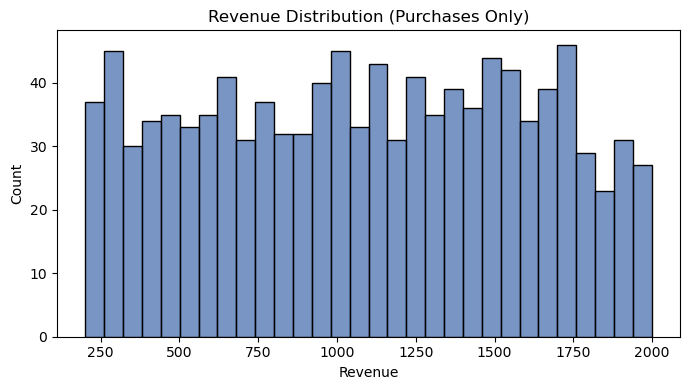

In [10]:
plt.figure(figsize=(7, 4))
sns.histplot(df[df['Revenue'] > 0]['Revenue'], bins=30, color='#4C72B0')
plt.title('Revenue Distribution (Purchases Only)')
plt.tight_layout()
plt.show()

In [11]:
# Basic Steps
print(f'Total User ID {df["User_ID"].nunique()}')
print(f'\nTotal Session ID {df["Session_ID"].nunique()}')
print(f'\nDate range {df["Date"].min()} to {df["Date"].max()}')

Total User ID 10000

Total Session ID 10000

Date range 2025-10-01 to 2025-10-31


Explaining why (max stage is not equal to last event)

In [12]:
# Define funnel stages in order

funnel_stages = ['Browse', 'Add to Cart', 'Checkout', 'Purchase']


# Create session-level summary

session_summary = df.groupby('Session_ID').agg({
    'User_ID': 'first',
    'Timestamp': ['min', 'max'],
    'Event': lambda x: list(x),
    'Device': 'first',
    'Region': 'first',
    'Channel': 'first',
    'Product_Category': 'first',
    'Revenue': 'max',
    'Bounce_Flag': 'first'
}).reset_index()

#Flatten column names
session_summary.columns = ['Session_ID', 'User_ID', 'Session_Start', 'Session_End', 'Event_Sequence', 'Device', 'Region',
       'Channel', 'Product_Category', 'Revenue', 'Bounce_Flag']
     

# Calculate session duration in minutes

session_summary['Session_Duration_Min'] = (
    session_summary['Session_End'] - session_summary['Session_Start']
).dt.total_seconds() / 60


# Identify maximum funnel stage reached for each session

def get_max_funnel_stage(events):
    stage_values = {stage: i for i, stage in enumerate(funnel_stages)}
    max_stage_index = -1

    for event in events:
        if event in stage_values and stage_values[event] > max_stage_index:
            max_stage_index = stage_values[event]

    return funnel_stages[max_stage_index] if max_stage_index != -1 else 'Browse'


session_summary['Max_Funnel_Stage'] = session_summary['Event_Sequence'].apply(get_max_funnel_stage)

print("📈 Session Summary Created:")
display(session_summary.head())

📈 Session Summary Created:


,Session_ID,User_ID,Session_Start,Session_End,Event_Sequence,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Session_Duration_Min,Max_Funnel_Stage
0,SES00001,USR00001,2025-10-28 07:33:50,2025-10-28 07:40:50,"[Browse, Add to Cart, Checkout]",Desktop,West,Organic,Home,0.00,Yes,7.0,Checkout
1,SES00002,USR00002,2025-10-19 09:15:10,2025-10-19 09:27:10,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Email,Electronics,448.18,No,12.0,Purchase
2,SES00003,USR00003,2025-10-12 02:19:00,2025-10-12 02:29:00,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Google Ads,Beauty,1437.19,No,10.0,Purchase
3,SES00004,USR00004,2025-10-05 17:55:48,2025-10-05 17:55:48,[Browse],Tablet,West,Social Media,Home,0.00,Yes,0.0,Browse
4,SES00005,USR00005,2025-10-19 12:35:49,2025-10-19 12:37:49,"[Browse, Add to Cart]",Tablet,West,Google Ads,Electronics,0.00,Yes,2.0,Add to Cart


## Overall Funnel Analysis

In [13]:
# Calculate overall funnel metrics

funnel_metrics = []

for i, stage in enumerate(funnel_stages):

    if i == 0:
        # For Browse stage, count all sessions
        count = len(session_summary)

    else:
        # For other stages, count sessions that reached at least this stage
        count = len(
            session_summary[
                session_summary['Max_Funnel_Stage'].isin(funnel_stages[i:])
            ]
        )

    funnel_metrics.append({
        'Stage': stage,
        'Sessions': count,
        'Stage_Order': i
    })


funnel_df = pd.DataFrame(funnel_metrics)


# Calculate conversion rates

funnel_df['Conversion_Rate'] = (
    funnel_df['Sessions'] / funnel_df['Sessions'].iloc[0] * 100
).round(2)

funnel_df['Drop_Off_Rate'] = (
    1 - funnel_df['Sessions'] / funnel_df['Sessions'].shift(1)
) * 100

funnel_df['Drop_Off_Rate'].iloc[0] = 0
funnel_df['Drop_Off_Rate'] = funnel_df['Drop_Off_Rate'].round(2)


print("🎯 Overall Funnel Analysis:")
display(funnel_df)

# Revenue analysis

revenue_stats = (
    session_summary[
        session_summary['Max_Funnel_Stage'] == 'Purchase'
    ].agg({
        'Revenue': ['sum', 'mean', 'count']
    }).round(2)
)

print("\n💰 Revenue Analysis:")
print(f"Total Revenue: ${revenue_stats.iloc[0, 0]:,.2f}")
print(f"Average Order Value: ${revenue_stats.iloc[1, 0]:,.2f}")
print(f"Total Orders: {revenue_stats.iloc[2, 0]}")

🎯 Overall Funnel Analysis:


C:\Users\ANURAG\AppData\Local\Temp\ipykernel_3184\836778357.py:39: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  funnel_df['Drop_Off_Rate'].iloc[0] = 0
C:\Users\ANURAG\AppData\Local\Temp\ipykernel_3184\836778357.py:39: SettingWithCopyWarning

,Stage,Sessions,Stage_Order,Conversion_Rate,Drop_Off_Rate
0,Browse,10000,0,100.00,0.00
1,Add to Cart,7059,1,70.59,29.41
2,Checkout,3524,2,35.24,50.08
3,Purchase,1080,3,10.80,69.35



💰 Revenue Analysis:
Total Revenue: $1,176,405.78
Average Order Value: $1,089.26
Total Orders: 1080.0


Visualization Overall Funnel

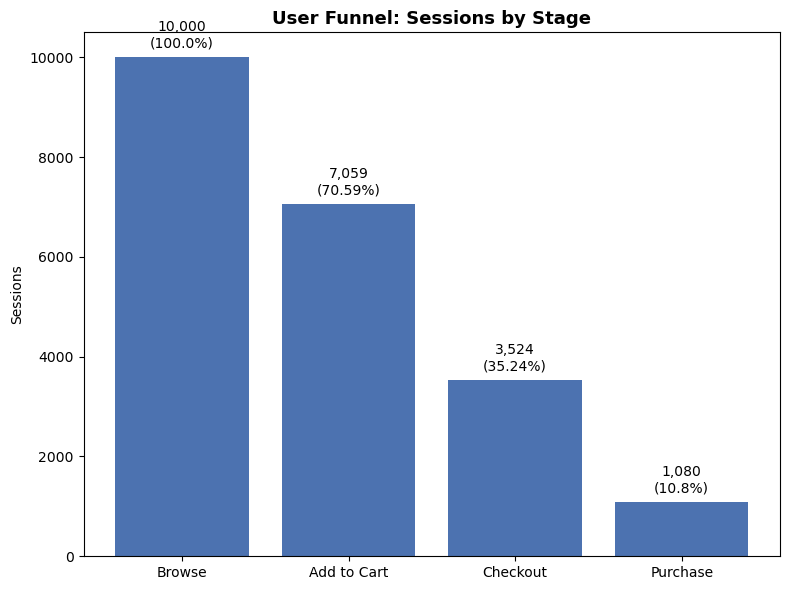

In [14]:
# Funnel visualization with drop-off annotations
plt.figure(figsize=(8, 6))

bars = plt.bar(funnel_df['Stage'], funnel_df['Sessions'], color='#4C72B0')

# Annotate each bar with session count and conversion %
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 200,
              f"{int(height):,}\n({funnel_df['Conversion_Rate'].iloc[i]}%)",
              ha='center', fontsize=10)

plt.title('User Funnel: Sessions by Stage', fontsize=13, fontweight='bold')
plt.ylabel('Sessions')
plt.tight_layout()
plt.show()

## Channel Performance Analysis

📊 Channel Summary:


,Channel,Total_Sessions,Total_Revenue
0,Email,2489,276116.54
1,Google Ads,2560,312769.26
2,Organic,2511,307448.35
3,Social Media,2440,280071.63


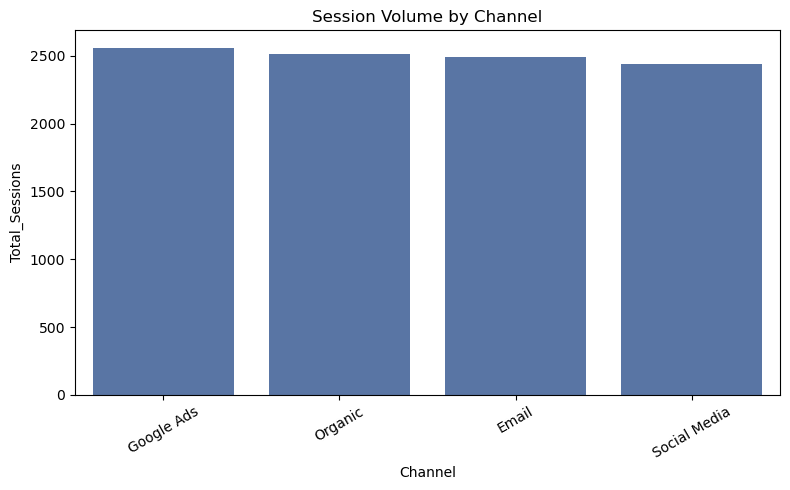

In [15]:
# Channel-level session and revenue summary
channel_df = (
    session_summary
    .groupby('Channel')
    .agg({
        'Session_ID': 'count',
        'Revenue': 'sum'
    })
    .rename(columns={'Session_ID': 'Total_Sessions', 'Revenue': 'Total_Revenue'})
    .reset_index()
)

print("📊 Channel Summary:")
display(channel_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=channel_df.sort_values('Total_Sessions', ascending=False),
            x='Channel', y='Total_Sessions', color='#4C72B0')
plt.title('Session Volume by Channel')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Regional Analysis

In [16]:
# Regional performance analysis

regional_analysis = (
    session_summary
    .groupby('Region')
    .agg({
        'Session_ID': 'count',
        'Revenue': 'sum',
        'Session_Duration_Min': 'mean'
    })
    .rename(columns={
        'Session_ID': 'Total_Sessions',
        'Revenue': 'Total_Revenue'
    })
)

# Add conversion rates by region

regional_conversion = (
    session_summary[
        session_summary['Max_Funnel_Stage'] == 'Purchase'
    ]
    .groupby('Region')
    .size()
)

regional_analysis['Converted_Sessions'] = regional_conversion

regional_analysis['Conversion_Rate'] = (
    regional_analysis['Converted_Sessions'] /
    regional_analysis['Total_Sessions'] * 100
).round(2)

regional_analysis['AOV'] = (
    regional_analysis['Total_Revenue'] /
    regional_analysis['Converted_Sessions']
).round(2)

print("🌍 Regional Performance:")
display(regional_analysis)


🌍 Regional Performance:


,Total_Sessions,Total_Revenue,Session_Duration_Min,Converted_Sessions,Conversion_Rate,AOV
Region,,,,,,
East,2514,301767.14,4.146778,280,11.14,1077.74
North,2504,288027.95,3.998003,261,10.42,1103.56
South,2506,311018.57,4.102155,282,11.25,1102.90
West,2476,275592.12,4.080775,257,10.38,1072.34


📱 Device Performance:


,Total_Sessions,Revenue,Session_Duration_Min,Purchases,Conversion_Rate,AOV
Device,,,,,,
Desktop,3331,399395.43,4.095167,372,11.17,1073.64
Mobile,3345,405451.84,4.061584,363,10.85,1116.95
Tablet,3324,371558.51,4.089350,345,10.38,1076.98


📦 Product Category Performance:


,Total_Sessions,Revenue,Purchases,Conversion_Rate,AOV,Revenue_Per_Session
Product_Category,,,,,,
Beauty,1978,241834.97,226,11.43,1070.07,122.26
Electronics,2046,226451.63,208,10.17,1088.71,110.68
Fashion,2035,237261.50,220,10.81,1078.46,116.59
Home,1941,232534.83,211,10.87,1102.06,119.80
Sports,2000,238322.85,215,10.75,1108.48,119.16


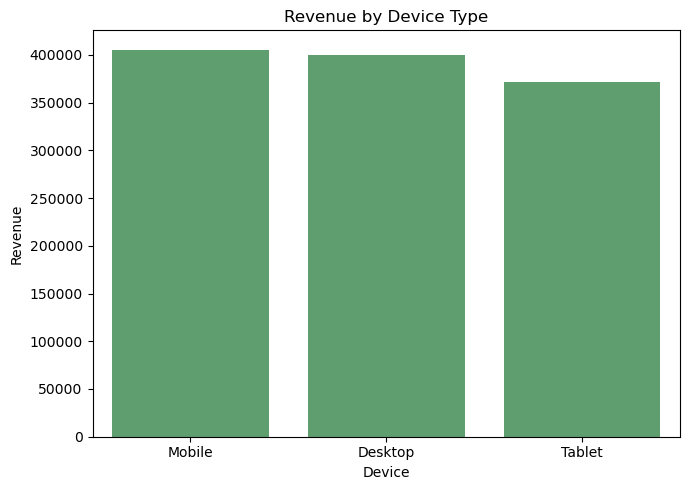

In [17]:
# Device performance
device_analysis = (
    session_summary
    .groupby('Device')
    .agg({
        'Session_ID': 'count',
        'Revenue': 'sum',
        'Session_Duration_Min': 'mean',
        'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
    })
    .rename(columns={
        'Session_ID': 'Total_Sessions',
        'Max_Funnel_Stage': 'Purchases'
    })
)

device_analysis['Conversion_Rate'] = (
    device_analysis['Purchases'] /
    device_analysis['Total_Sessions'] * 100
).round(2)

device_analysis['AOV'] = (
    device_analysis['Revenue'] /
    device_analysis['Purchases']
).round(2)

print("📱 Device Performance:")
display(device_analysis)


# Product category analysis
product_analysis = (
    session_summary
    .groupby('Product_Category')
    .agg({
        'Session_ID': 'count',
        'Revenue': 'sum',
        'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
    })
    .rename(columns={
        'Session_ID': 'Total_Sessions',
        'Max_Funnel_Stage': 'Purchases'
    })
)

product_analysis['Conversion_Rate'] = (
    product_analysis['Purchases'] /
    product_analysis['Total_Sessions'] * 100
).round(2)

product_analysis['AOV'] = (
    product_analysis['Revenue'] /
    product_analysis['Purchases']
).round(2)

product_analysis['Revenue_Per_Session'] = (
    product_analysis['Revenue'] /
    product_analysis['Total_Sessions']
).round(2)

print("📦 Product Category Performance:")
display(product_analysis)


# Revenue by device — single chart, no subplots
plt.figure(figsize=(7, 5))
sns.barplot(data=device_analysis.reset_index().sort_values('Revenue', ascending=False),
            x='Device', y='Revenue', color='#55A868')
plt.title('Revenue by Device Type')
plt.tight_layout()
plt.show()

## Time Based Analysis

📅 Daily Performance:


,Daily_Sessions,Daily_Users,Revenue
Date,,,
2025-10-22,300,300,33633.64
2025-10-23,347,347,50983.83
2025-10-24,315,315,39543.10
2025-10-25,364,364,50965.19
2025-10-26,355,355,42548.29
2025-10-27,310,310,41315.66
2025-10-28,347,347,39963.77
2025-10-29,336,336,29960.83
2025-10-30,331,331,35412.95


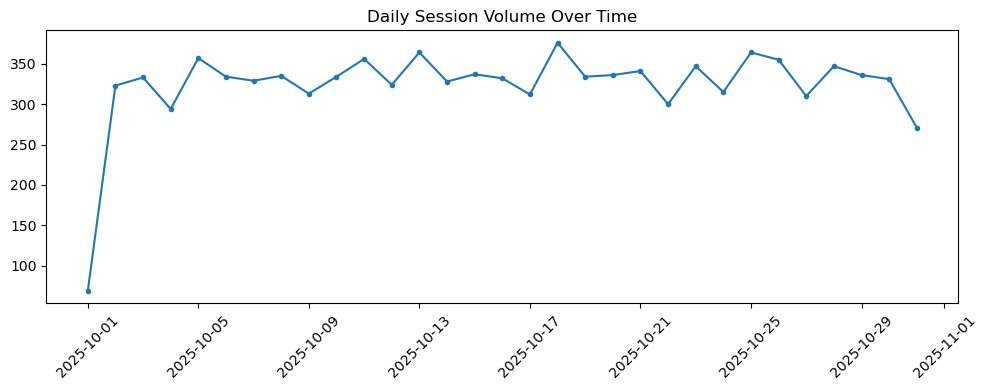

In [18]:
# Daily trends
daily_metrics = df.groupby('Date').agg({
    'Session_ID': 'nunique',
    'User_ID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={
    'Session_ID': 'Daily_Sessions',
    'User_ID': 'Daily_Users'
})

print("📅 Daily Performance:")
display(daily_metrics.tail(10))

plt.figure(figsize=(10, 4))
plt.plot(daily_metrics.index, daily_metrics['Daily_Sessions'], marker='o', markersize=3)
plt.title('Daily Session Volume Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Observations

- **Overall conversion rate is 10.80%** (1,080 purchases out of 10,000 sessions) — roughly 9 in 10 sessions never convert to a sale
- **Stage-to-stage conversion rates:**
  - Browse → Add to Cart: 70.59%
  - Add to Cart → Checkout: 49.92%
  - Checkout → Purchase: 30.65%
- **The steepest relative drop happens at Checkout → Purchase**, where fewer than 1 in 3 sessions that reach checkout actually complete a purchase — this is the single largest leakage point in the funnel and the priority area for the recommendations phase
- **Bounce rate is 89.2%**, consistent with the heavy early-stage drop-off already seen above
- **Total revenue is ~$1.18M** across 1,080 completed orders, giving an **average order value of ~$1,089**
- Revenue and session volume look reasonably distributed across channels and devices, with no single segment dominating — deeper segment-level comparisons (which channel/region/device converts best) are covered in the SQL phase

In [22]:
# ============================
# Prepare Data for PostgreSQL
# ============================

df_sql = df.copy()

# 1. Rename columns to snake_case
df_sql = df_sql.rename(columns={
    'User_ID': 'user_id',
    'Session_ID': 'session_id',
    'Event': 'event',
    'Timestamp': 'event_timestamp',
    'Device': 'device',
    'Region': 'region',
    'Channel': 'channel',
    'Product_Category': 'product_category',
    'Revenue': 'revenue',
    'Bounce_Flag': 'bounce_flag'
})

# 2. Drop columns we'll rebuild in SQL instead
cols_to_drop = ['Date', 'DayOfWeek', 'Hour', 'WeekNumber', 'Event_sequence']
df_sql = df_sql.drop(columns=[c for c in cols_to_drop if c in df_sql.columns])

# 3. Fix data types
df_sql['event_timestamp'] = pd.to_datetime(df_sql['event_timestamp'])
df_sql['revenue'] = df_sql['revenue'].astype(float).round(2)
df_sql['bounce_flag'] = df_sql['bounce_flag'].map({'Yes': True, 'No': False})

# 4. Sanity check before export
print(df_sql.dtypes)
print(df_sql.isnull().sum())
display(df_sql.head())

# 5. Export final CSV for PostgreSQL import
df_sql.to_csv('funnel_analysis_clean.csv', index=False)
print("✅ Exported funnel_analysis_clean.csv — ready for PostgreSQL import")

user_id                     object
session_id                  object
event                       object
event_timestamp     datetime64[ns]
device                      object
region                      object
channel                     object
product_category            object
revenue                    float64
bounce_flag                   bool
dtype: object
user_id             0
session_id          0
event               0
event_timestamp     0
device              0
region              0
channel             0
product_category    0
revenue             0
bounce_flag         0
dtype: int64


,user_id,session_id,event,event_timestamp,device,region,channel,product_category,revenue,bounce_flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,True
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,True
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,True
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,False
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,False


✅ Exported funnel_analysis_clean.csv — ready for PostgreSQL import
